On commence par un cas de classification tabulaire avec une regression logisitique sur 5 datasets de UCI.
Ensuite on s'intéresse à de la classification par Image et aux propriétées des classifieurs obtenus par Nll, PO(I) et PO(Beta^Star).

In [1]:
!git clone https://github.com/gabrielsinger2/nll_to_po.git

Cloning into 'nll_to_po'...
remote: Enumerating objects: 404, done.
remote: Counting objects: 100% (404/404), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 404 (delta 168), reused 384 (delta 152), pack-reused 0 (from 0)
Receiving objects: 100% (404/404), 13.67 MiB | 34.39 MiB/s, done.
Resolving deltas: 100% (168/168), done.


In [ ]:
%cd /content/nll_to_po
%pip install -e .

# Redémarre le runtime pour que l'import prenne bien:
import os, sys; os.kill(os.getpid(), 9)


/content/nll_to_po
Obtaining file:///content/nll_to_po
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
Reason for being yanked: Missing schema files
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.2/113.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.1/112.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.8 MB/s eta 0:00:00
  Building editable for NLL_TO_PO (pyproject.toml) ... done
  Created wheel for NLL_TO_PO: filename=nll_to_po-0.1.dev78+g48e3c3a2a-0.editable-py3-none-any.whl size=2958 sha256=6f6c04a20053f56399bf5a83f223aafe582de42fcdb899c4b561ad7436bab7ef
  Stored in directory: /tmp/pip-ephem-wheel-cache-9txows41/wheels/f1/01/15/fba5bed4fe0537add64a1c5ea59048dcaccbbc751ec3089f42
Succes

In [1]:
# !pip install scikit-learn pandas matplotlib seaborn torch --quiet

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_wine, load_breast_cancer, load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

import nll_to_po.training.loss as L
import nll_to_po.training.reward as R
import nll_to_po.models.dn_policy as Policy
from nll_to_po.training.utils import train_single_policy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

sns.set_theme(style="whitegrid", font_scale=1.5)
sns.set_palette("colorblind")
sns.despine()

<Figure size 640x480 with 0 Axes>

In [2]:
def load_uci(
    dataset="wine", test_size=0.2, val_size=0.2, batch_size=256, standardize=True
):
    if dataset == "wine":
        data = load_wine()
    if dataset == "wine":
        data = load_wine()
    elif dataset == "iris":
        data = load_iris()
    elif dataset == "breast_cancer":
        data = load_breast_cancer()
    elif dataset == "load_digits":
        data = load_digits()
    else:
        raise ValueError(f"Unknown dataset: {dataset}")
    X, y = data.data, data.target
    if standardize:
        scaler = StandardScaler().fit(X)
        X = scaler.transform(X)

    # train / (val+test)
    X_tr, X_tt, y_tr, y_tt = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=0
    )
    # split val from train
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=0
    )
    # conversion en tensor type pour le donner au dataloader
    X_tr = torch.tensor(X_tr, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    X_tt = torch.tensor(X_tt, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_val = torch.tensor(y_val, dtype=torch.long)
    y_tt = torch.tensor(y_tt, dtype=torch.long)

    tr_loader = DataLoader(
        TensorDataset(X_tr, y_tr, y_tr, torch.zeros_like(y_tr)),
        batch_size=batch_size,
        shuffle=True,
    )
    # on ne shuffle pas la val et le test
    val_loader = DataLoader(
        TensorDataset(X_val, y_val, y_val, torch.zeros_like(y_val)),
        batch_size=batch_size,
        shuffle=False,
    )
    tst_loader = DataLoader(
        TensorDataset(X_tt, y_tt, y_tt, torch.zeros_like(y_tt)),
        batch_size=batch_size,
        shuffle=False,
    )

    meta = {"input_dim": X.shape[1], "num_classes": len(np.unique(y))}
    return tr_loader, val_loader, tst_loader, meta


train_loader, val_loader, test_loader, meta = load_uci("wine", batch_size=128)

Set up $\widehat{Y}$ c'est le one hot encoding des labels Y et je travaille avec les one hot encoding

In [18]:
@torch.no_grad()
def Estimate_trace_sigma_onehot(train_loader, num_classes: int) -> float:
    #modification pour qu'elle accetpe nimporte quel dataloader avec des labels en deuxieme position
    ys = []
    print("Estimating trace of label covariance matrix...")
    for _, yb, *rest in train_loader:
        ys.append(yb)
    print("Done")
    y = torch.cat(ys, dim=0)  # (N,)
    Y = F.one_hot(y, num_classes=num_classes).float()  # (N,C)
    Yc = Y - Y.mean(dim=0, keepdim=True)  # (N,C)
    Sigma = (Yc.T @ Yc) / max(Y.shape[0] - 1, 1)  # (C,C)
    return float(torch.trace(Sigma))

import torch

def _trace_from_counts(counts: torch.Tensor) -> float:
    """
    counts: 1D Long tensor of length C with class counts.
    """
    N = int(counts.sum().item())
    if N <= 1:
        return 0.0
    p2_sum = (counts.float() / N).pow(2).sum().item()
    return float((N / (N - 1)) * (1.0 - p2_sum))

@torch.no_grad()
def estimate_trace_sigma_onehot(train_loader, num_classes: int, device: str = "cpu") -> float:
    print('in estimate_trace_sigma_onehot')
    """
    Fast: streams the loader once, accumulates class counts via bincount.
    Works with any DataLoader where labels are at index 1.
    Accepts integer labels or one-hot labels (NxC).
    """
    counts = torch.zeros(num_classes, dtype=torch.long, device=device) # Create counts tensor on the specified device
    print("finished counts")
    print("len(dataset) =", len(train_loader.dataset))
    print("len(loader)  =", len(train_loader))  # nb de batches attendu

    for batch in train_loader:
        yb = batch[1].to(device) # Move yb to the specified device
        # If labels are one-hot, convert to class indices
        if yb.ndim == 2 and yb.size(1) == num_classes:
            yb = yb.argmax(dim=1)
        yb = yb.to(torch.long).flatten()
        counts += torch.bincount(yb, minlength=num_classes)
    return _trace_from_counts(counts)



def beta_star_from_data(train_loader, entropy_weight: float, num_classes: int, device: str = "cpu") -> float:
    print('in beta_star_from_data')
    tr = estimate_trace_sigma_onehot(train_loader, num_classes=num_classes, device=device) # Pass device to estimate_trace_sigma_onehot
    return float(entropy_weight * num_classes / (2.0 * max(tr, 1e-12)))

In [23]:
@torch.no_grad()
def evaluate_accuracy_multi_regression(
    policy: nn.Module, data_loader: DataLoader, device: str = "cuda"
) -> float:
    policy.to(device)
    policy.eval()
    correct, total = 0, 0
    for xb, yb, *rest in data_loader:
        # yb est un vecteur [num_samples] a valeur dans les labes [0;1,...,C-1]
        xb, yb = xb.to(device), yb.to(device) # Move data to device
        _, prob_predit = policy(xb)
        # one_hot_pred = prob_predit.argmax(dim=-1)
        # print(f'prob shape {prob_predit.shape}')
        # print(f'one hot true shape {yb.shape}')
        y_prob = prob_predit.argmax(dim=-1)
        correct += (y_prob == yb).sum().item()
        total += yb.numel()
    if total == 1:
        return "One element in the dataloader"
    else:
        return correct / max(total, 1)

In [5]:
import numpy as np
import tensorflow_datasets
from tensorflow_datasets.core.utils.lazy_imports_utils import pandas as pd
from tensorflow_datasets.core.utils.lazy_imports_utils import tensorflow as tf

human_labels_np_path = '/content/nll_to_po/notebook/CIFAR_NOISY_DATA/CIFAR-10_human.npy'
human_labels_csv_path = '/content/nll_to_po/notebook/CIFAR_NOISY_DATA/CIFAR-10_human_annotations.csv'

with tf.io.gfile.GFile(human_labels_np_path, "rb") as f:
  human_annotations = np.load(f, allow_pickle=True)

df = pd.DataFrame(human_annotations[()])

with tf.io.gfile.GFile(human_labels_csv_path, "w") as f:
  df.to_csv(f, index=False)


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler, Dataset
from torchvision import datasets, transforms
from PIL import Image
from typing import Optional, Dict

# CIFAR-10 normalization
_CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
_CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

class CIFAR10NTrain(Dataset):
    """
    Wraps torchvision CIFAR-10 (train=True) and replaces labels by a provided array (len=50000).
    Keeps the image order intact.
    """
    def __init__(self, root: str, noisy_labels: np.ndarray, transform=None, download: bool = True):
        base = datasets.CIFAR10(root=root, train=True, download=download)
        assert len(base.data) == 50000 and len(noisy_labels) == 50000
        self.data = base.data                      # N x 32 x 32 x 3 (uint8)
        self.labels = noisy_labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int):
        img = Image.fromarray(self.data[idx])
        y = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        # Return placeholder tensors for mu and std to match the expected format
        return img, y, torch.zeros_like(torch.tensor(y, dtype=torch.float32)), torch.zeros_like(torch.tensor(y, dtype=torch.float32))

def _load_cifar10n_labels(
    human_labels_np_path: Optional[str] = None,
    human_labels_dict: Optional[Dict[str, np.ndarray]] = None,
) -> Dict[str, np.ndarray]:
    """
    Load the CIFAR-10N dict from a .npy file (allow_pickle=True) or accept a preloaded dict.
    Returns a dict with keys like: 'clean_label', 'aggre_label', 'worse_label', 'random_label1/2/3', ...
    """
    if human_labels_dict is None:
        assert human_labels_np_path is not None, "Provide human_labels_np_path or human_labels_dict."
        d = np.load(human_labels_np_path, allow_pickle=True)
        # Some .npy store a 0-d object array containing the dict
        if isinstance(d, np.ndarray) and d.dtype == object:
            human_labels_dict = d.item()
        elif isinstance(d, dict):
            human_labels_dict = d
        else:
            raise ValueError("Unexpected CIFAR-10N npy format; expected dict or object array with dict.")
    return human_labels_dict

def load_cifar10n_dataset(
    batch_size: int = 128,
    data_root: str = "./data",
    label_key: str = "random_label1",
    val_fraction: float = 0.2,
    seed: int = 0,
    human_labels_np_path: Optional[str] = None,
    human_labels_dict: Optional[Dict[str, np.ndarray]] = None,
    download: bool = False,
):
    """
    Returns (train_loader, val_loader, test_loader, meta) using CIFAR-10 images and CIFAR-10N labels.

    - Train/Val split is performed on the 50k training images (shuffle once with `seed`).
    - Labels for BOTH train and val come from `label_key` (noisy validation, like your MNIST helper).
      If you want a clean-val variant, ask and I’ll add a switch.
    - Test set is the standard clean CIFAR-10 test.
    """
    # --- transforms ---
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(_CIFAR10_MEAN, _CIFAR10_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(_CIFAR10_MEAN, _CIFAR10_STD),
    ])

    # --- load CIFAR-10N label dict ---
    labels_dict = _load_cifar10n_labels(human_labels_np_path, human_labels_dict)

    # Support the common typo 'worst_label' -> 'worse_label'
    if label_key == "worst_label" and "worse_label" in labels_dict:
        label_key = "worse_label"

    assert label_key in labels_dict, f"{label_key=} not found. Available: {list(labels_dict.keys())}"
    noisy_labels = np.asarray(labels_dict[label_key])
    assert noisy_labels.shape == (50000,), "CIFAR-10N labels must be length 50000."

    dl_kwargs = dict(num_workers=0, pin_memory=False, persistent_workers=False)

    # --- datasets ---
    # Modify to include placeholder tensors for mu and std
    train_val_dataset = CIFAR10NTrain(root=data_root, noisy_labels=noisy_labels, transform=train_tf, download=download)
    test_dataset_base = datasets.CIFAR10(root=data_root, train=False, download=download, transform=eval_tf)

    # Create a dataset for the test set that also includes placeholder tensors
    class CIFAR10TestWithPlaceholders(Dataset):
        def __init__(self, base_dataset):
            self.base = base_dataset

        def __len__(self):
            return len(self.base)

        def __getitem__(self, idx):
            # Unpack all returned values and take the first two
            data = self.base[idx]
            img, y = data[0], data[1]
            return img, y, torch.zeros_like(torch.tensor(y, dtype=torch.float32)), torch.zeros_like(torch.tensor(y, dtype=torch.float32))

    test_dataset = CIFAR10TestWithPlaceholders(test_dataset_base)

    # --- split 80/20 like your MNIST helper ---
    num_train = len(train_val_dataset)  # 50k
    indices = np.arange(num_train)
    split = int(val_fraction * num_train)
    rng = np.random.RandomState(seed)
    rng.shuffle(indices)
    val_idx, train_idx = indices[:split], indices[split:]

    train_loader = DataLoader(
        train_val_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx), **dl_kwargs
    )
    # Use eval transforms for val (no aug). Create a shallow copy with eval_tf.
    # Easiest: re-instantiate a view of the dataset but with eval_tf for the same labels.
    # Modify to include placeholder tensors for mu and std
    val_dataset_evalview_base = CIFAR10NTrain(root=data_root, noisy_labels=noisy_labels, transform=eval_tf, download=False)
    val_dataset_evalview = CIFAR10TestWithPlaceholders(val_dataset_evalview_base)

    val_loader = DataLoader(
        val_dataset_evalview, batch_size=batch_size, sampler=SubsetRandomSampler(val_idx), **dl_kwargs
    )

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **dl_kwargs)

    meta = {
        "in_channels": 3,
        "num_classes": 10,
        "image_size": (32, 32),
        "mean": _CIFAR10_MEAN,
        "std": _CIFAR10_STD,
        "label_key": label_key,
    }
    return train_loader, val_loader, test_loader, meta

In [7]:
human_labels_np_path = "/content/nll_to_po/notebook/CIFAR_NOISY_DATA/CIFAR-10_human.npy"

train_loader, val_loader, test_loader, meta = load_cifar10n_dataset(
    batch_size=128,
    data_root="./data",
    label_key="random_label2",
    val_fraction=0.2,
    seed=0,
    human_labels_np_path=human_labels_np_path,
    download=True,
)

print(meta)

100%|██████████| 170M/170M [00:01<00:00, 106MB/s]


{'in_channels': 3, 'num_classes': 10, 'image_size': (32, 32), 'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'label_key': 'random_label2'}


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import torch

def load_mnist_dataset(batch_size: int = 128):
    transform = transforms.Compose([transforms.ToTensor()])  # (B,1,28,28) dans [0,1]
    train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
    test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    # Split train -> train/val (80/20)
    num_train = len(train_dataset)
    indices = np.arange(num_train)
    split = int(0.2 * num_train)
    rng = np.random.RandomState(0)
    rng.shuffle(indices)
    val_idx, train_idx = indices[:split], indices[split:]

    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx))
    val_loader   = DataLoader(train_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(val_idx))
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    meta = {"in_channels": 1, "num_classes": 10, "image_size": (28, 28)}
    return train_loader, val_loader, test_loader, meta


In [9]:
train_loader, val_loader, test_loader, meta=load_mnist_dataset(batch_size=256)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


In [10]:
len(set([1,1,1,2]))

2

In [11]:
import torch
from nll_to_po.models.dn_policy import CNNClassifier

In [12]:
model = CNNClassifier(in_channels=1, num_classes=10)
x = torch.randn(128, 1, 28, 28)
logits, probs = model(x)
print(logits.shape, probs.shape)  # -> torch.Size([128, 10]) torch.Size([128, 10])



torch.Size([128, 10]) torch.Size([128, 10])


In [40]:
def run_one_dataset(
    dataset_name: str,
    n_updates: int = 10,
    n_experiments: int = 5,
    batch_size: int = 128,
    learning_rate: float = 1e-4,
    entropy_weight: float = 1e-3,
    type_of_data : str = "tabular",
    corrupted_inputs: bool = False,
):
    if type_of_data=="tabular":
        print(f"Running on tabular dataset: {dataset_name}")
        train_loader, val_loader, test_loader, meta = load_uci(
        dataset=dataset_name, batch_size=batch_size, standardize=True
        )
        C = meta["num_classes"]
        D_in = meta["input_dim"]
    elif type_of_data=="image" and dataset_name=="mnist":
        print(f"Running on {dataset_name}")
        train_loader, val_loader, test_loader, meta = load_mnist_dataset(
            batch_size=batch_size
        )
        C = meta["num_classes"]
        D_in = meta["in_channels"]
    elif type_of_data=="image" and dataset_name=="cifar10n":
        # Corrected path to the .npy file
        human_labels_np_path = "/content/nll_to_po/notebook/CIFAR_NOISY_DATA/CIFAR-10_human.npy"

        train_loader, val_loader, test_loader, meta = load_cifar10n_dataset(
            batch_size=128,
            data_root="./data",
            label_key="random_label2",
            val_fraction=0.2,
            seed=0,
            human_labels_np_path=human_labels_np_path,
        )
        C=meta["num_classes"]
        D_in=meta["in_channels"]

    print('finished to load datasets')
    beta_star = beta_star_from_data(
        train_loader, entropy_weight=entropy_weight, num_classes=C, device="cuda"
    )
    print(f"Estimated beta_star: {beta_star:.4e}")
    # beta_list = [1, beta_star]
    beta_list = [2 * beta_star, beta_star]

    curves = []
    tests = []

    for rep in range(n_experiments):
        # policy = MLPClassifier(D_in, C)
        if type_of_data=="tabular":
            policy = Policy.MulticlassLogisticRegression(D_in, C)
        elif type_of_data=="image":
            policy = Policy.ResNet18Vanilla(num_classes=C, in_channels=3)
        loss_fn = L.NLL_Classification()
        print("start training NLL")
        trained_policy, train_metrics, val_metrics, _, _ = train_single_policy(
            policy=policy,
            train_dataloader=train_loader,
            val_dataloader=val_loader,
            loss_function=loss_fn,
            n_updates=n_updates,
            learning_rate=learning_rate,
            wandb_run=None,
            tensorboard_writer=None,
            logger=None,
            scheduler_patience=20, device=torch.device("cuda")
        )

        df_tr = (
            pd.DataFrame(train_metrics).reset_index().rename(columns={"index": "epoch"})
        )
        df_tr["split"] = "train"
        df_tr["method"] = "NLL"
        df_tr["beta"] = np.nan
        df_tr["rep"] = rep
        df_val = (
            pd.DataFrame(val_metrics).reset_index().rename(columns={"index": "epoch"})
        )
        df_val["split"] = "val"
        df_val["method"] = "NLL"
        df_val["beta"] = np.nan
        df_val["rep"] = rep
        curves += [df_tr, df_val]

        # test_acc = evaluate_accuracy(policy, test_loader)
        test_acc = evaluate_accuracy_multi_regression(trained_policy, test_loader)
        tests.append(
            {
                "dataset": dataset_name,
                "method": "NLL",
                "beta": np.nan,
                "rep": rep,
                "test_accuracy": test_acc,
            }
        )

    for beta in beta_list:
        U = torch.eye(C) * float(beta)
        U=U.to('cuda')
        reward = R.OneHotMahalanobis(U, num_classes=C)  # reward
        print(f"Running Policy Optimization for {beta}")
        for rep in range(n_experiments):
            policy = Policy.ResNet18Vanilla(num_classes=C, in_channels=3)
            loss_fn = L.PO_Entropy_Classification(
                reward_fn=reward,
                n_generations=50,
                use_rsample=False,
                reward_transform="none",
                entropy_weight=entropy_weight,
            )

            beta_trained_policy, train_metrics, val_metrics, _, _ = train_single_policy(
                policy=policy,
                train_dataloader=train_loader,
                val_dataloader=val_loader,
                loss_function=loss_fn,
                n_updates=n_updates,
                learning_rate=learning_rate,
                wandb_run=None,
                tensorboard_writer=None,
                logger=None,
                early_stopping_patience=20, device=torch.device("cuda")
            )

            df_tr = (
                pd.DataFrame(train_metrics)
                .reset_index()
                .rename(columns={"index": "epoch"})
            )
            df_tr["split"] = "train"
            df_tr["method"] = "PO_Entropy"
            df_tr["beta"] = beta
            df_tr["rep"] = rep
            df_val = (
                pd.DataFrame(val_metrics)
                .reset_index()
                .rename(columns={"index": "epoch"})
            )
            df_val["split"] = "val"
            df_val["method"] = "PO_Entropy"
            df_val["beta"] = beta
            df_val["rep"] = rep
            curves += [df_tr, df_val]

            # test_acc = evaluate_accuracy(policy, test_loader)
            test_acc = evaluate_accuracy_multi_regression(
                beta_trained_policy, test_loader
            )
            tests.append(
                {
                    "dataset": dataset_name,
                    "method": "PO_Entropy",
                    "beta": beta,
                    "rep": rep,
                    "test_accuracy": test_acc,
                }
            )

    curves_df = pd.concat(curves, ignore_index=True)
    tests_df = pd.DataFrame(tests)
    curves_df["is_beta_star"] = curves_df["beta"].apply(
        lambda b: isinstance(b, float) and abs(b - beta_star) < 1e-12
    )
    tests_df["is_beta_star"] = tests_df["beta"].apply(
        lambda b: isinstance(b, float) and abs(b - beta_star) < 1e-12
    )
    return curves_df, tests_df, beta_star

In [37]:
def plot_curves_for_dataset(
    curves_df: pd.DataFrame, dataset_name: str, beta_star: float
):
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    # helpers
    def make_label(row):
        if row["method"] == "NLL":
            return "NLL"
        if pd.isna(row["beta"]):
            return "PO (β=NA)"
        if abs(row["beta"] - beta_star) < 1e-12:
            return "PO (β*)"
        return f"PO (β={row['beta']:.3g})"

    curves_df = curves_df.copy()
    curves_df["label"] = curves_df.apply(make_label, axis=1)

    # colors: NLL blue, β* black, others red
    palette_map = {}
    for lab in curves_df["label"].unique():
        if lab == "NLL":
            palette_map[lab] = "#1f77b4"
        elif lab == "PO (β*)":
            palette_map[lab] = "black"
        else:
            palette_map[lab] = "red"

    # TRAIN
    sub = curves_df[curves_df["split"] == "train"]
    sns.lineplot(
        data=sub,
        x="epoch",
        y="accuracy",
        hue="label",
        errorbar=("ci", 95),
        ax=ax[0],
        palette=palette_map,
        legend=False,
    )
    ax[0].set_title(f"{dataset_name}: Train accuracy vs epoch")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("accuracy")

    # VAL
    sub = curves_df[curves_df["split"] == "val"]
    sns.lineplot(
        data=sub,
        x="epoch",
        y="accuracy",
        hue="label",
        errorbar=("ci", 95),
        ax=ax[1],
        palette=palette_map,
        legend=True,
    )
    ax[1].set_title(f"{dataset_name}: Val accuracy vs epoch")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("accuracy")
    ax[1].legend(title="method", frameon=False, loc="lower right")

    plt.tight_layout()
    plt.show()

In [38]:
def show_test_table(tests_df: pd.DataFrame, dataset_name: str):
    keep = (tests_df["method"] == "PO_Entropy") | (tests_df["method"] == "NLL")
    df = tests_df[keep].copy()

    grouped = (
        df.groupby(["dataset", "method", "is_beta_star"], dropna=False)["test_accuracy"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    def beta_label(row):
        if row["method"] == "NLL":
            return "—"
        return "β*" if row["is_beta_star"] else "β=1"

    grouped["beta_label"] = grouped.apply(beta_label, axis=1)
    grouped = grouped[["dataset", "method", "beta_label", "mean", "std", "count"]]
    grouped = grouped[grouped["dataset"] == dataset_name]

    print(f"Test accuracy summary — {dataset_name}")
    display(grouped.style.format({"mean": "{:.4f}", "std": "{:.4f}"}))

In [16]:
#datasets = ["iris"]

#all_curves = []
#all_tests = []

#for ds in datasets:
#    curves_df, tests_df, bstar = run_one_dataset(
#        dataset_name=ds,
#        n_updates=100,
#        n_experiments=100,
#        batch_size=128,
#        learning_rate=1e-2,
#        entropy_weight=1e-1,
#        type_of_data= "tabular"
#    )
#    plot_curves_for_dataset(curves_df, ds, bstar)
#    show_test_table(tests_df, ds)

#    curves_df["dataset"] = ds
#    tests_df["dataset"] = ds
#    all_curves.append(curves_df)
#    all_tests.append(tests_df)

#df_curves_all = pd.concat(all_curves, ignore_index=True)
#df_tests_all = pd.concat(all_tests, ignore_index=True)

finished to load datasets
in beta_star_from_data
in estimate_trace_sigma_onehot
finished counts
len(dataset) = 50000
len(loader)  = 313
Estimated beta_star: 5.5576e-01
start training NLL


Training epochs: 100%|██████████| 50/50 [18:54<00:00, 22.69s/it]


Running Policy Optimization for 1.111527326074871


Training epochs:  40%|████      | 20/50 [08:11<12:17, 24.60s/it]


Running Policy Optimization for 0.5557636630374355


Training epochs:  40%|████      | 20/50 [08:10<12:15, 24.51s/it]


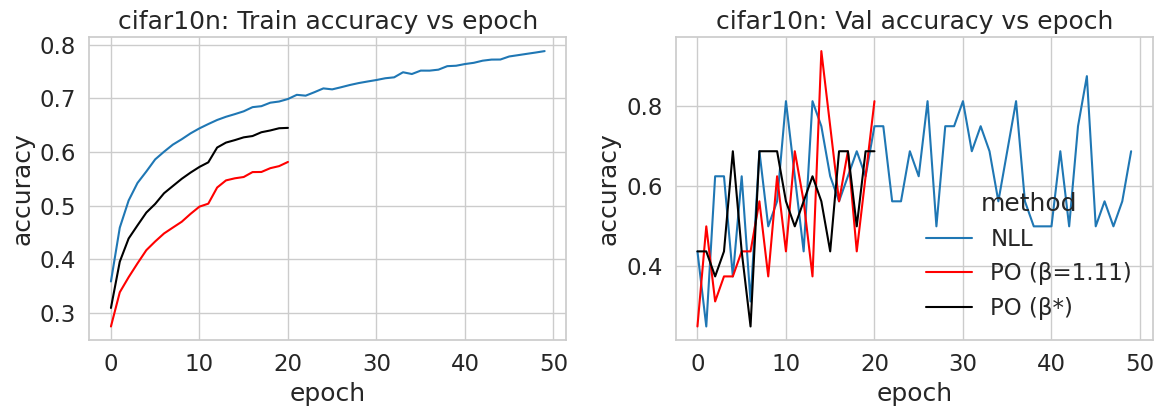

Test accuracy summary — cifar10n


,dataset,method,beta_label,mean,std,count
0,cifar10n,NLL,—,0.7883,nan,1
1,cifar10n,PO_Entropy,β=1,0.6591,nan,1
2,cifar10n,PO_Entropy,β*,0.7364,nan,1


In [42]:
Datasets = ["cifar10n"]

all_curves = []
all_tests = []

for ds in Datasets:
    curves_df, tests_df, bstar = run_one_dataset(
        dataset_name=ds,
        n_updates=50,
        n_experiments=1,
        batch_size=256,
        learning_rate=1e-3,
        entropy_weight=1e-1, type_of_data="image"
    )
    plot_curves_for_dataset(curves_df, ds, bstar)
    show_test_table(tests_df, ds)

    curves_df["dataset"] = ds
    tests_df["dataset"] = ds
    all_curves.append(curves_df)
    all_tests.append(tests_df)

df_curves_all = pd.concat(all_curves, ignore_index=True)
df_tests_all = pd.concat(all_tests, ignore_index=True)

In [ ]:
from torchvision import models
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, datasets, transforms
import matplotlib.pyplot as plt
import pickle
import urllib.request

import numpy as np
from PIL import Image


In [ ]:
model=models.resnet18(pretrained=False)

In [ ]:
model.eval()
classes = pickle.load(urllib.request.urlopen('https://gist.githubusercontent.com/yrevar/6135f1bd8dcf2e0cc683/raw/d133d61a09d7e5a3b36b8c111a8dd5c4b5d560ee/imagenet1000_clsid_to_human.pkl'))
